## Plotting spring time series for event selection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.linear_model import LinearRegression
from scipy.signal import find_peaks, peak_prominences

# tau
shear_stress_full = pd.read_csv('../../data/shear_stress/average_total_shear_stress_corrected.csv', parse_dates=['datetime'], index_col='datetime')
# sonde data
down_sonde = pd.read_csv('../../data/sonde_data/sonde_down_full_record_smoothed.csv', parse_dates=['DateTime'], index_col='DateTime')
up_sonde = pd.read_csv('../../data/sonde_data/sonde_up_full_record_smoothed.csv', parse_dates=['DateTime'], index_col='DateTime')
# nutrient data
down_constituents = pd.read_csv('../../data/constituents/SP23_down_constituents.csv', parse_dates=['Date_Time'], index_col='Date_Time')
up_constituents = pd.read_csv('../../data/constituents/SP23_up_constituents.csv', parse_dates=['Date_Time'], index_col='Date_Time')

# determine dates of spring: 
min_date = pd.Timestamp('2023-04-15')
max_date = pd.Timestamp('2023-05-09')

# filter data to spring period
tau = shear_stress_full.loc[(shear_stress_full.index >= min_date) & (shear_stress_full.index <= max_date)]
down_sonde = down_sonde.loc[(down_sonde.index >= min_date) & (down_sonde.index <= max_date)]
up_sonde = up_sonde.loc[(up_sonde.index >= min_date) & (up_sonde.index <= max_date)]

# in sonde data sets, delete rows with negative data 
down_sonde = down_sonde[(down_sonde['Turbidity FNU'] >= 0) & (down_sonde['fDOM RFU'] >= 0) & (down_sonde['fDOM RFU'] <= 2)]
up_sonde = up_sonde[(up_sonde['Turbidity FNU'] >= 0) & (up_sonde['fDOM RFU'] >= 0) & (up_sonde['fDOM RFU'] <= 3)]

Turbidity Time Series

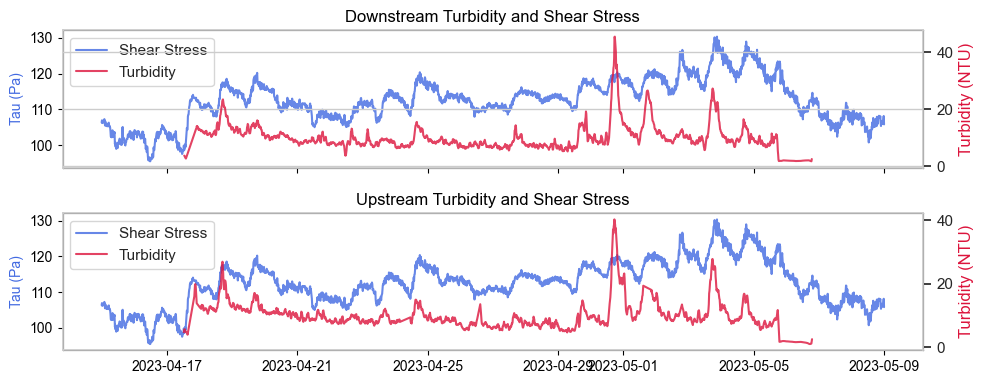

In [ ]:
# plot tau and turbidity time series for reaches
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")
colors = ['royalblue', 'crimson']
labels = ['Shear Stress', 'Turbidity']
ylabels = ['Tau (Pa)', 'Turbidity (NTU)']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau['shear_stress'], label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(False)

    ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    ax_tau.set_title(titles[i])
    lines, labs = ax_tau.get_legend_handles_labels()
    lines2, labs2 = ax_turb.get_legend_handles_labels()
    ax_tau.legend(lines + lines2, labs + labs2, loc='upper left')

plt.grid(False)
plt.tight_layout()
plt.show()

fDOM Time Series

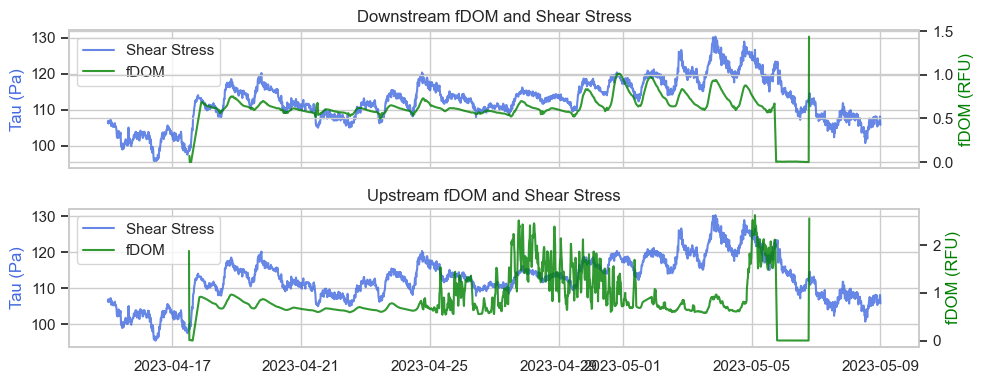

In [ ]:
# plot tau and turbidity time series for reaches
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")
colors = ['royalblue', 'green']
labels = ['Shear Stress', 'fDOM']
ylabels = ['Tau (Pa)', 'fDOM (RFU)']
data = [down_sonde, up_sonde]
titles = ['Downstream fDOM and Shear Stress', 'Upstream fDOM and Shear Stress']

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau['shear_stress'], label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(True)

    ax_turb.plot(sonde.index, sonde['fDOM RFU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    ax_tau.set_title(titles[i])
    lines, labs = ax_tau.get_legend_handles_labels()
    lines2, labs2 = ax_turb.get_legend_handles_labels()
    ax_tau.legend(lines + lines2, labs + labs2, loc='upper left')

plt.grid(False)
plt.tight_layout()
plt.show()

Determining event peaks

In [ ]:
# resample discharge to 1 min to have matching time steps with sonde data 
tau_resampled = tau.resample('1min').interpolate()
# merge shear stress to the sonde dataframe 
down_sonde = down_sonde.merge(tau_resampled, left_index=True, right_index=True, how='left')
up_sonde = up_sonde.merge(tau_resampled, left_index=True, right_index=True, how='left')

up_sonde

,Turbidity FNU,fDOM RFU,shear_stress
DateTime,,,
2023-04-17 12:29:00,4.774567,1.877722,99.781269
2023-04-17 12:44:00,5.592353,0.010305,98.649383
2023-04-17 12:59:00,5.686188,0.008818,98.998976
2023-04-17 13:14:00,5.725505,0.010098,99.113353
2023-04-17 13:29:00,5.349801,0.008423,100.156806
...,...,...,...
2023-05-06 17:59:00,1.121984,0.000000,112.495492
2023-05-06 18:14:00,1.169017,0.000000,112.622849
2023-05-06 18:29:00,1.206398,0.000000,112.079504


In [ ]:
# tau is second column
tau = down_sonde['shear_stress']
# smooth slightly
tau_smooth = tau.rolling(6, center=True).mean()

# find peaks
peak_idx, _ = find_peaks(
    tau_smooth,
    prominence=3,   
    distance=12    
)

peak_times = tau_smooth.index[peak_idx]
window = pd.Timedelta(hours=9)

events = []

for peak in peak_idx:
    peak_time = tau_smooth.index[peak]

    start_time = peak_time - window
    end_time = peak_time + window

    start_time = max(start_time, tau_smooth.index[0])
    end_time = min(end_time, tau_smooth.index[-1])

    events.append({
        'events': f'Event_{len(events)+1}',
        'start': start_time,
        'peak_time': peak_time,
        'end': end_time,
        'peak_tau': tau_smooth.iloc[peak],
        'max_turbidity_down': down_sonde.loc[start_time:end_time, 'Turbidity FNU'].max(),
        'max_turbidity_up': up_sonde.loc[start_time:end_time, 'Turbidity FNU'].max(),
        'max_fDOM_down': down_sonde.loc[start_time:end_time, 'fDOM RFU'].max(),
        'max_fDOM_up': up_sonde.loc[start_time:end_time, 'fDOM RFU'].max()
    })

events = pd.DataFrame(events)
print(events)

      events               start           peak_time                 end  \
0    Event_1 2023-04-17 13:18:00 2023-04-17 22:18:00 2023-04-18 07:18:00   
1    Event_2 2023-04-18 11:18:00 2023-04-18 20:18:00 2023-04-19 05:18:00   
2    Event_3 2023-04-19 09:03:00 2023-04-19 18:03:00 2023-04-20 03:03:00   
3    Event_4 2023-04-21 09:33:00 2023-04-21 18:33:00 2023-04-22 03:33:00   
4    Event_5 2023-04-22 14:18:00 2023-04-22 23:18:00 2023-04-23 08:18:00   
5    Event_6 2023-04-23 11:18:00 2023-04-23 20:18:00 2023-04-24 05:18:00   
6    Event_7 2023-04-24 08:48:00 2023-04-24 17:48:00 2023-04-25 02:48:00   
7    Event_8 2023-04-27 11:48:00 2023-04-27 20:48:00 2023-04-28 05:48:00   
8    Event_9 2023-04-29 11:18:00 2023-04-29 20:18:00 2023-04-30 05:18:00   
9   Event_10 2023-04-30 10:48:00 2023-04-30 19:48:00 2023-05-01 04:48:00   
10  Event_11 2023-05-01 14:33:00 2023-05-01 23:33:00 2023-05-02 08:33:00   
11  Event_12 2023-05-02 10:33:00 2023-05-02 19:33:00 2023-05-03 04:33:00   
12  Event_13

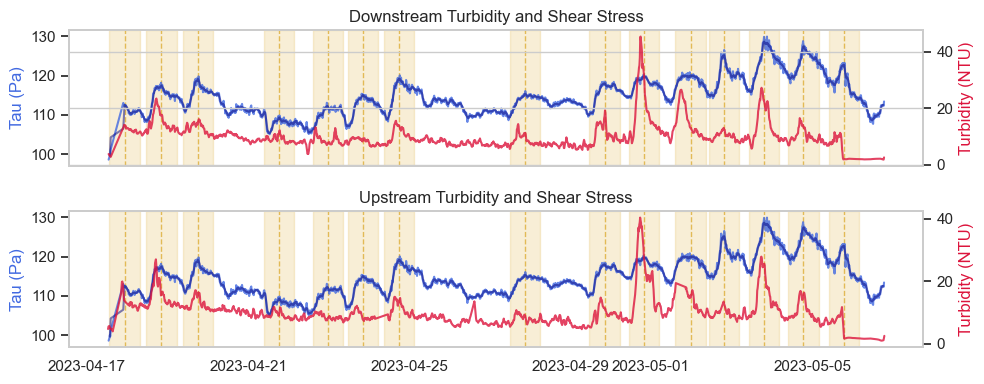

In [ ]:
# plot tau and turbidity time series for reaches, with event spans
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")

colors = ['royalblue', 'crimson']
labels = ['Shear Stress', 'Turbidity']
ylabels = ['Tau (Pa)', 'Turbidity (NTU)']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']

event_color = 'goldenrod'
event_alpha = 0.18

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau, label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.plot(tau_smooth.index, tau_smooth, label='Smoothed Tau', color='navy', alpha=0.5)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(False)

    ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    for j, row in events.iterrows():
        ax_tau.axvspan(
            row['start'],
            row['end'],
            color=event_color,
            alpha=event_alpha,
            zorder=0,
            label='Event window' if j == 0 else None
        )
        ax_tau.axvline(
            row['peak_time'],
            color=event_color,
            linestyle='--',
            linewidth=1,
            alpha=0.7,
            zorder=1,
            label='Event peak' if j == 0 else None
        )

    ax_tau.set_title(titles[i])

plt.grid(False)
plt.tight_layout()
plt.show()

## Refining start and end dates in each event

In [ ]:
colors = ['royalblue', 'crimson']
labels = ['Shear Stress', 'Turbidity']
ylabels = ['Tau (Pa)', 'Turbidity (NTU)']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']
event_color = 'goldenrod'
event_alpha = 0.18

def plot_event_window(event_idx):
    pad_left = pd.Timedelta(hours=6)
    pad_right = pd.Timedelta(hours=6)

    event = events.iloc[event_idx]
    plot_start = event['start'] - pad_left
    plot_end = event['end'] + pad_right

    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    sns.set_theme(style="whitegrid")

    for i, sonde in enumerate(data):
        ax_tau = ax[i]
        ax_turb = ax_tau.twinx()

        ax_tau.plot(tau.index, tau, label=labels[0], color=colors[0], alpha=0.8)
        ax_tau.set_ylabel(ylabels[0], color=colors[0])
        ax_tau.tick_params(axis='x', labelsize=8, rotation=45)
        ax_tau.grid(False)

        ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
        ax_turb.set_ylabel(ylabels[1], color=colors[1])
        ax_turb.tick_params(axis='x', labelsize=8, rotation=45)
        ax_turb.grid(False)

        ax_tau.axvspan(event['start'], event['end'], color=event_color, alpha=event_alpha, zorder=0, label='Event window')
        ax_tau.axvline(event['peak_time'], color=event_color, linestyle='--', linewidth=1, alpha=0.7, zorder=1, label='Event peak')

        ax_tau.set_xlim(plot_start, plot_end)
        ax_tau.set_title(f"{titles[i]} - Event {event_idx + 1}")

    plt.grid(False)
    plt.tight_layout()
    plt.show()

Event 1: 04/17

start        2023-04-17 13:00:00
peak_time    2023-04-17 22:18:00
end          2023-04-18 11:00:00
Name: 0, dtype: object


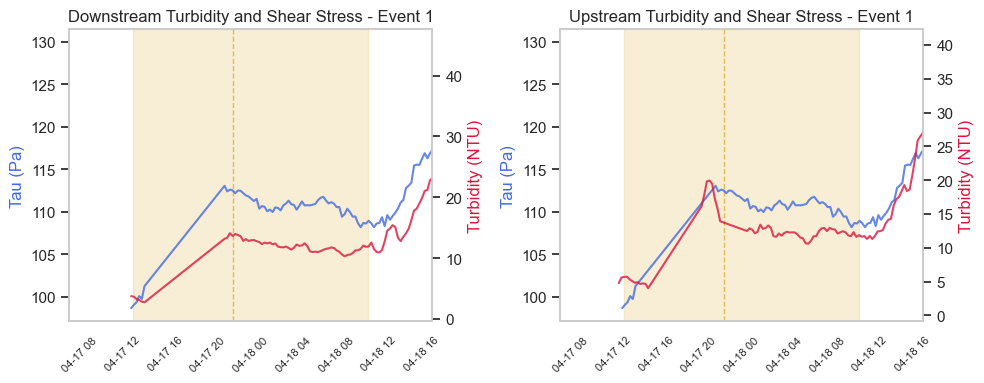

In [ ]:
event_idx = 0  # first event

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-17 13:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-18 11:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 2: 04/18

start        2023-04-18 11:00:00
peak_time    2023-04-18 20:18:00
end          2023-04-19 10:00:00
Name: 1, dtype: object


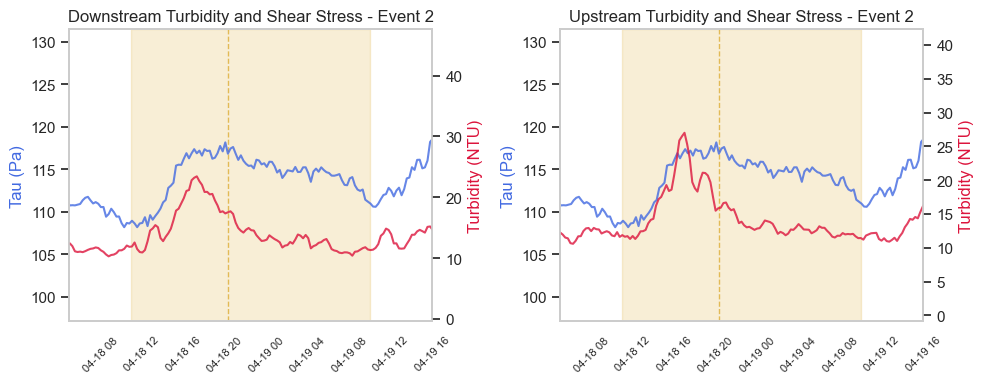

In [ ]:
event_idx = 1 

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-18 11:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-19 10:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 3: 04/19

start        2023-04-19 10:00:00
peak_time    2023-04-19 18:03:00
end          2023-04-20 11:00:00
Name: 2, dtype: object


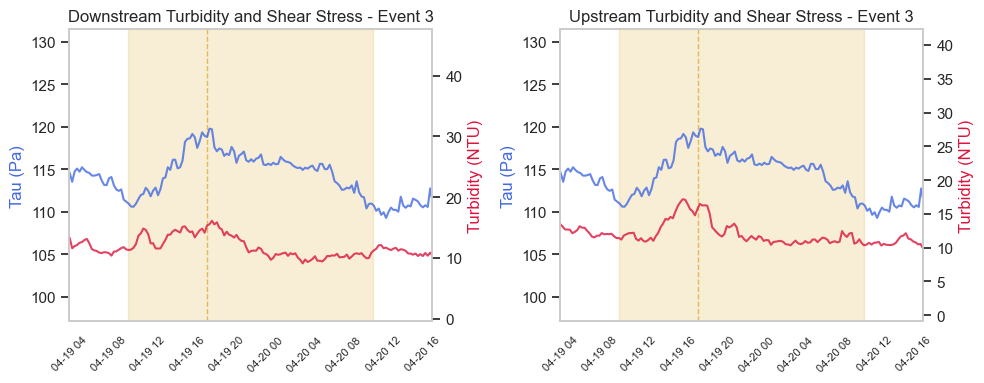

In [ ]:
event_idx = 2 

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-19 10:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-20 11:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 4: 04/21

start        2023-04-21 12:00:00
peak_time    2023-04-21 18:33:00
end          2023-04-22 09:30:00
Name: 3, dtype: object


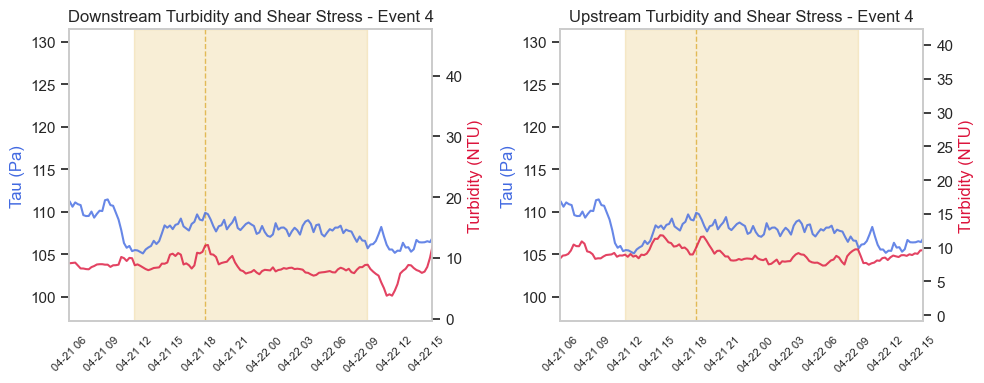

In [ ]:
event_idx = 3 

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-21 12:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-22 9:30')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 5: 04/22

start        2023-04-22 14:00:00
peak_time    2023-04-22 23:18:00
end          2023-04-23 10:30:00
Name: 4, dtype: object


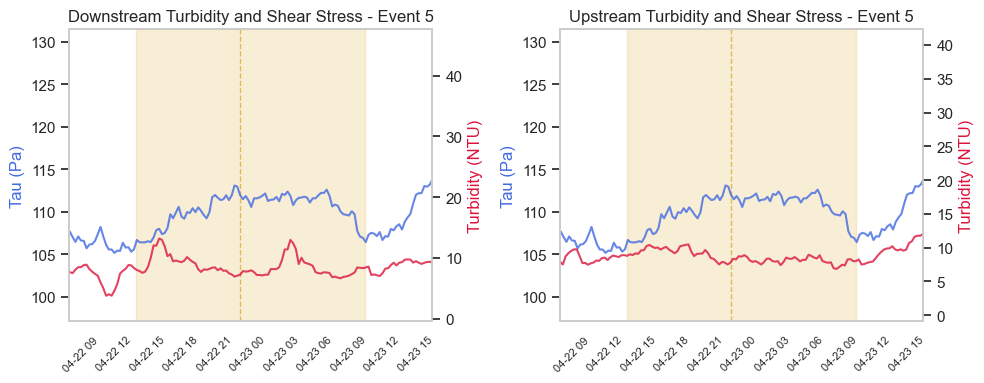

In [ ]:
event_idx = 4

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-22 14:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-23 10:30')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 6: 04/23

start        2023-04-23 11:30:00
peak_time    2023-04-23 20:18:00
end          2023-04-24 11:00:00
Name: 5, dtype: object


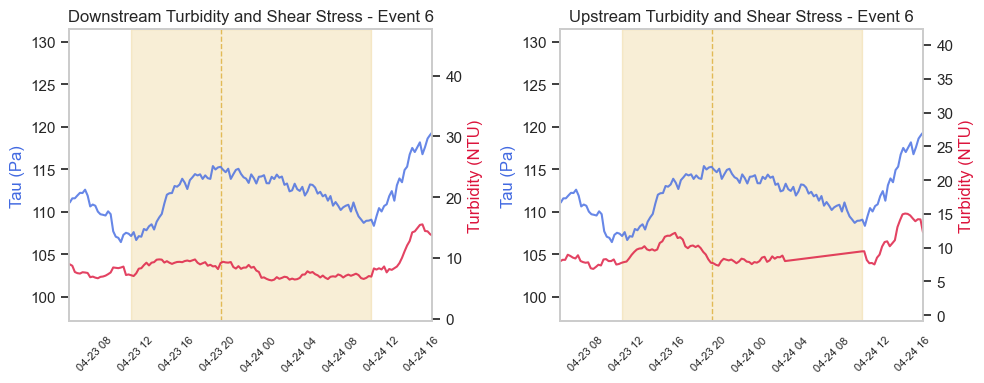

In [ ]:
event_idx = 5

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-23 11:30')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-24 11:0')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 7: 04/24

start        2023-04-24 11:00:00
peak_time    2023-04-24 17:48:00
end          2023-04-25 11:00:00
Name: 6, dtype: object


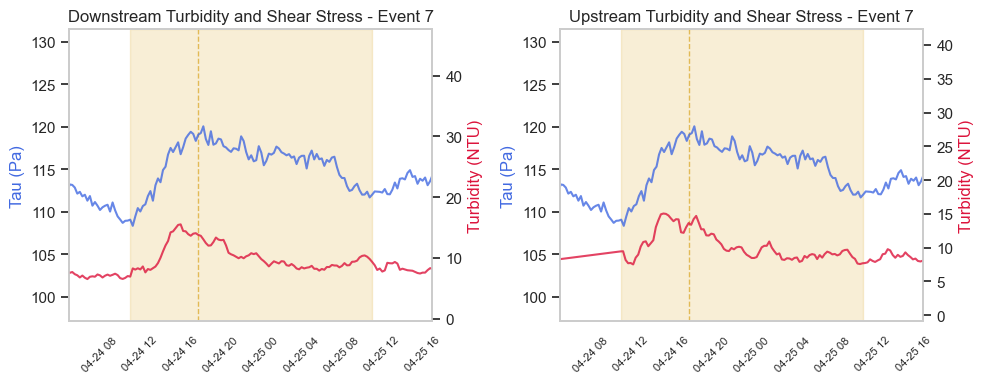

In [ ]:
event_idx = 6

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-24 11:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-25 11:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 8: 04/27

start        2023-04-27 12:00:00
peak_time    2023-04-27 20:48:00
end          2023-04-28 12:00:00
Name: 7, dtype: object


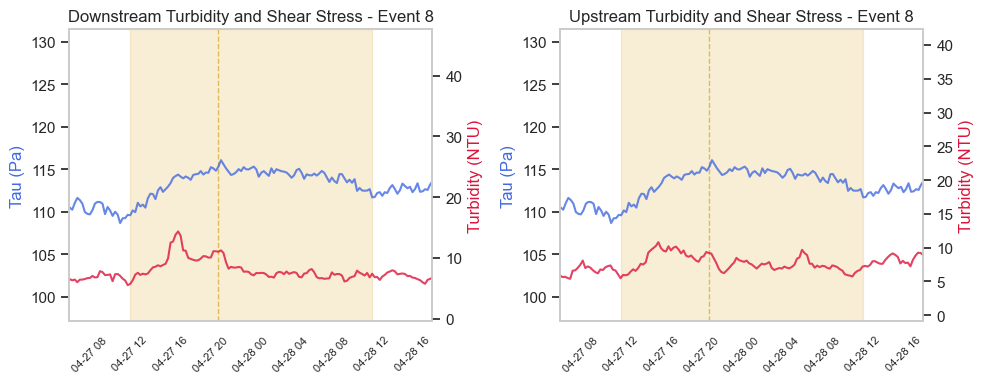

In [ ]:
event_idx = 7

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-27 12:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-28 12:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 9: 04/29

start        2023-04-29 12:00:00
peak_time    2023-04-29 20:18:00
end          2023-04-30 12:00:00
Name: 8, dtype: object


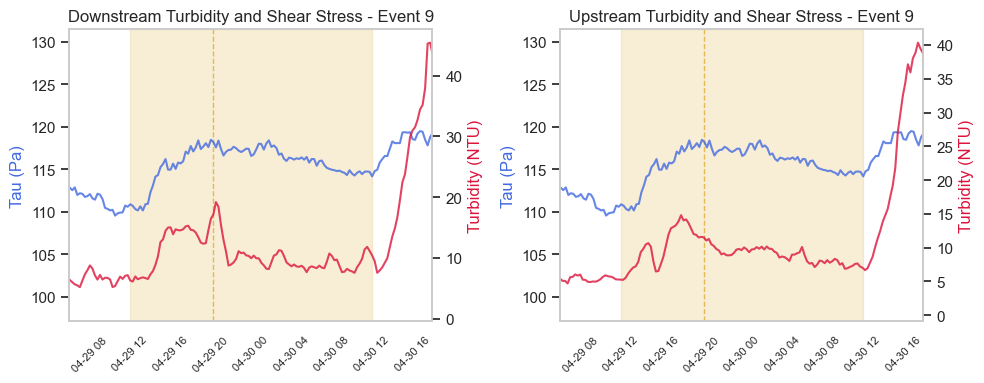

In [ ]:
event_idx = 8

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-29 12:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-04-30 12:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 10: 04/30

start        2023-04-30 12:00:00
peak_time    2023-04-30 19:48:00
end          2023-05-01 11:00:00
Name: 9, dtype: object


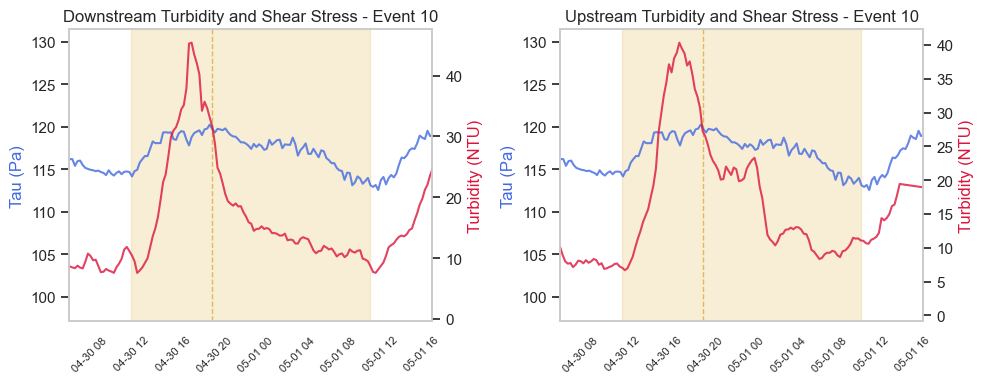

In [ ]:
event_idx = 9

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-04-30 12:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-05-01 11:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 11: 05/01

start        2023-05-01 11:00:00
peak_time    2023-05-01 23:33:00
end          2023-05-02 13:00:00
Name: 10, dtype: object


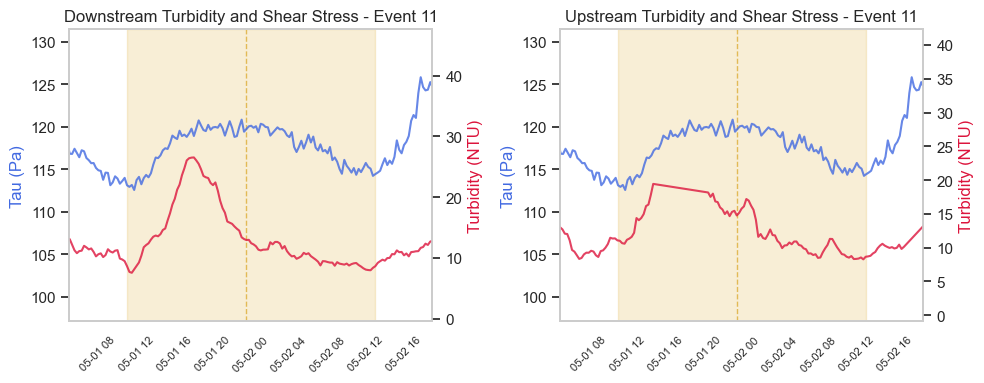

In [ ]:
event_idx = 10

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-05-01 11:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-05-02 13:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 12: 05/02

start        2023-05-02 13:00:00
peak_time    2023-05-02 19:33:00
end          2023-05-03 11:30:00
Name: 11, dtype: object


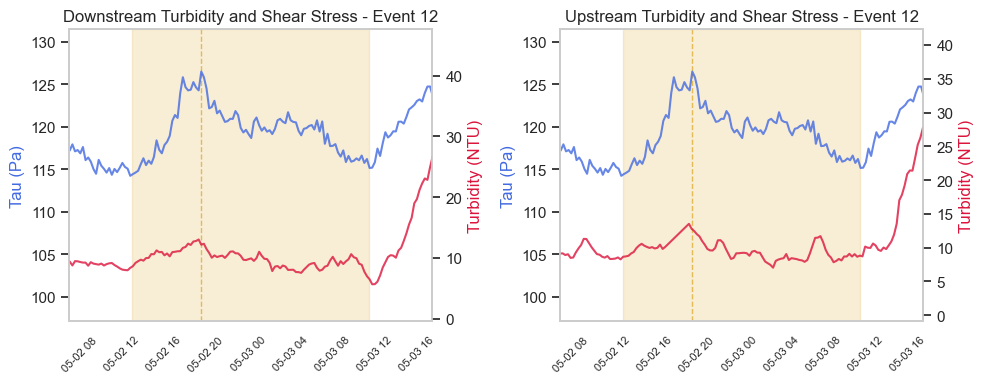

In [ ]:
event_idx = 11

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-05-02 13:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-05-03 11:30')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 13: 05/03

start        2023-05-03 11:30:00
peak_time    2023-05-03 19:18:00
end          2023-05-04 10:00:00
Name: 12, dtype: object


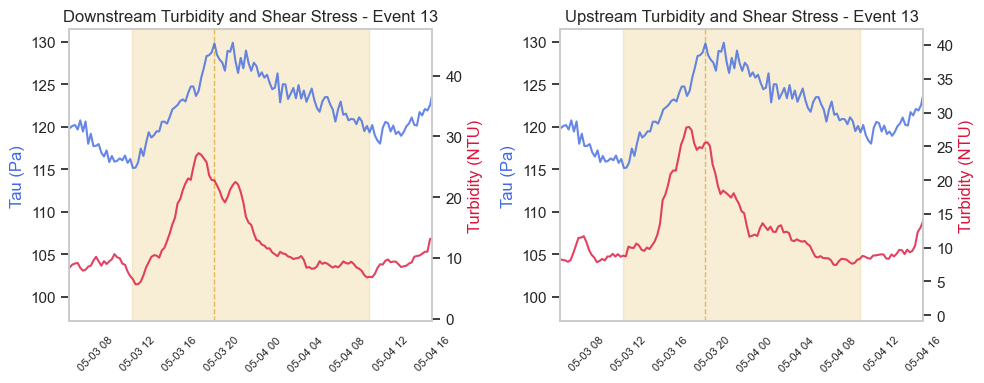

In [ ]:
event_idx = 12

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-05-03 11:30')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-05-04 10:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 14: 05/04

start        2023-05-04 11:00:00
peak_time    2023-05-04 18:48:00
end          2023-05-05 09:00:00
Name: 13, dtype: object


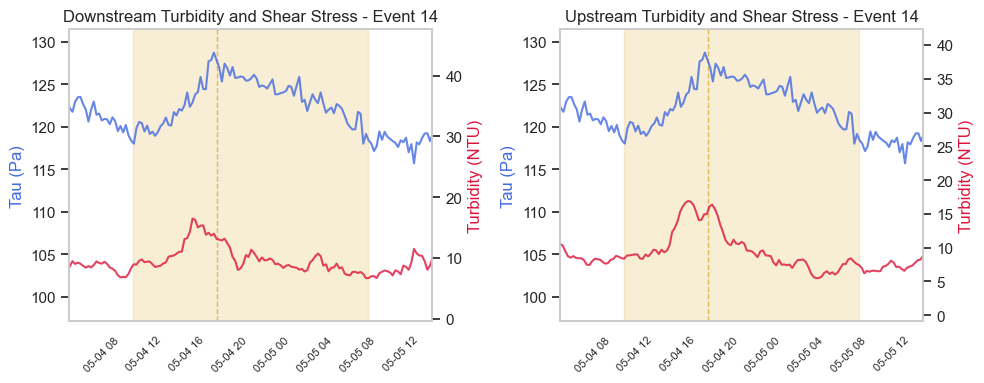

In [ ]:
event_idx = 13

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-05-04 11:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-05-05 9:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

Event 15: 05/05

start        2023-05-05 10:00:00
peak_time    2023-05-05 18:48:00
end          2023-05-06 09:00:00
Name: 14, dtype: object


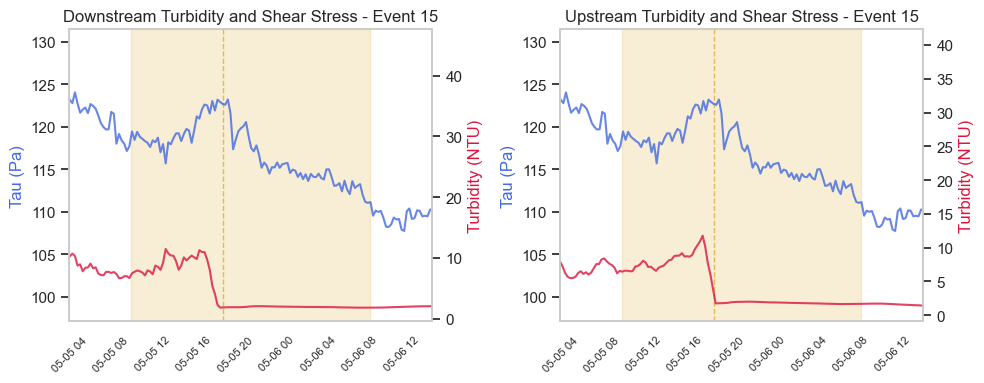

In [ ]:
event_idx = 14

events.loc[events.index[event_idx], 'start'] = pd.Timestamp('2023-05-05 10:00')
events.loc[events.index[event_idx], 'end'] = pd.Timestamp('2023-05-06 9:00')

print(events.loc[events.index[event_idx], ['start', 'peak_time', 'end']])
plot_event_window(event_idx)

## Plot time series of new event start and ends 

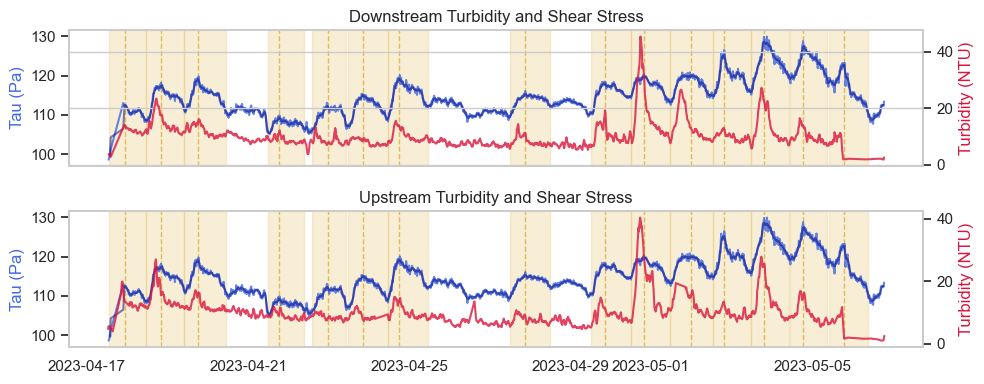

In [ ]:
# plot tau and turbidity time series for reaches, with event spans
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau, label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.plot(tau_smooth.index, tau_smooth, label='Smoothed Tau', color='navy', alpha=0.5)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(False)

    ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    for j, row in events.iterrows():
        ax_tau.axvspan(
            row['start'],
            row['end'],
            color=event_color,
            alpha=event_alpha,
            zorder=0,
            label='Event window' if j == 0 else None
        )
        ax_tau.axvline(
            row['peak_time'],
            color=event_color,
            linestyle='--',
            linewidth=1,
            alpha=0.7,
            zorder=1,
            label='Event peak' if j == 0 else None
        )

    ax_tau.set_title(titles[i])

plt.grid(False)
plt.tight_layout()
plt.show()

Export event dates to csv

In [ ]:
# export events to csv
events.to_csv('spring_events.csv', index=False)

## Critical Shear Stress Exceedance

Import and organize tauc_exceedance

In [ ]:
tauc_exceedance = pd.read_csv('../../data/hydrophones/spring_tauc50_exceedance_times.csv', parse_dates=['Time'], index_col='Time')

In [39]:
tauc_exceedance.index = pd.to_datetime(tauc_exceedance.index)
tauc_exceedance = tauc_exceedance.sort_index()

# group consecutive exceedance timestamps into transport events
expected_step = pd.Timedelta(minutes=15)
# start a new event when the gap between exceedance timestamps is > expected_step
gap = tauc_exceedance.index.to_series().diff()
new_event = gap.gt(expected_step) | gap.isna()
tauc_exceedance["transport_event_id"] = new_event.cumsum()

# summarize each transport event
tauc_exceedance_events = (tauc_exceedance.groupby("transport_event_id").agg(
        start=("Max Amp", lambda x: x.index.min()),
        end=("Max Amp", lambda x: x.index.max()),
        n_points=("Max Amp", "count"),
        max_amp=("Max Amp", "max"),
        max_dmax=("Dmax (mm)", "max")
    )
    .reset_index())

# duration based on timestamps
tauc_exceedance_events["duration"] = (tauc_exceedance_events["end"] - tauc_exceedance_events["start"] + expected_step)
tauc_exceedance_events["duration_hours"] = (
    tauc_exceedance_events["duration"].dt.total_seconds() / 3600)

tauc_exceedance_events

,transport_event_id,start,end,n_points,max_amp,max_dmax,duration,duration_hours
0,1,2023-04-15 13:45:00,2023-04-15 13:45:00,1,0.010910,61.98688,0 days 00:15:00,0.25
1,2,2023-04-19 15:45:00,2023-04-19 17:30:00,8,0.014100,60.71043,0 days 02:00:00,2.00
2,3,2023-04-21 22:45:00,2023-04-21 22:45:00,1,0.008700,45.47138,0 days 00:15:00,0.25
3,4,2023-04-22 06:45:00,2023-04-22 06:45:00,1,0.007870,44.75703,0 days 00:15:00,0.25
4,5,2023-04-22 08:00:00,2023-04-22 08:00:00,1,0.007890,44.80774,0 days 00:15:00,0.25
...,...,...,...,...,...,...,...,...
71,72,2023-05-04 17:00:00,2023-05-04 17:15:00,2,0.010582,46.71300,0 days 00:30:00,0.50
72,73,2023-05-04 18:15:00,2023-05-04 18:15:00,1,0.009705,44.26400,0 days 00:15:00,0.25
73,74,2023-05-04 18:45:00,2023-05-04 18:45:00,1,0.009293,44.30000,0 days 00:15:00,0.25
74,75,2023-05-05 01:00:00,2023-05-05 01:00:00,1,0.009826,46.13500,0 days 00:15:00,0.25


Identify which spring event has tauc exceedance

In [40]:
events = events.copy()
events["start"] = pd.to_datetime(events["start"])
events["end"] = pd.to_datetime(events["end"])
events["peak_time"] = pd.to_datetime(events["peak_time"])
event_rows = []

for _, event in events.iterrows():
    overlapping_transport = tauc_exceedance_events[
        (tauc_exceedance_events["start"] <= event["end"]) &
        (tauc_exceedance_events["end"] >= event["start"])
    ]

    event_rows.append({
        "event": event.get("event", event.name),
        "event_start": event["start"],
        "event_peak": event["peak_time"],
        "event_end": event["end"],
        "has_tauc_exceedance": not overlapping_transport.empty,
        "n_transport_events": len(overlapping_transport),
        "n_exceedance_points": overlapping_transport["n_points"].sum() if not overlapping_transport.empty else 0,
        "total_exceedance_hours": overlapping_transport["duration_hours"].sum() if not overlapping_transport.empty else 0,
        "max_Dmax_mm": overlapping_transport["max_dmax"].max() if not overlapping_transport.empty else np.nan
    })

event_tauc_summary = pd.DataFrame(event_rows)
event_tauc_summary

,event,event_start,event_peak,event_end,has_tauc_exceedance,n_transport_events,n_exceedance_points,total_exceedance_hours,max_Dmax_mm
0,0,2023-04-17 13:00:00,2023-04-17 22:18:00,2023-04-18 11:00:00,False,0,0,0.00,NaN
1,1,2023-04-18 11:00:00,2023-04-18 20:18:00,2023-04-19 10:00:00,False,0,0,0.00,NaN
2,2,2023-04-19 10:00:00,2023-04-19 18:03:00,2023-04-20 11:00:00,True,1,8,2.00,60.71043
3,3,2023-04-21 12:00:00,2023-04-21 18:33:00,2023-04-22 09:30:00,True,5,5,1.25,45.71622
4,4,2023-04-22 14:00:00,2023-04-22 23:18:00,2023-04-23 10:30:00,True,6,7,1.75,46.06356
5,5,2023-04-23 11:30:00,2023-04-23 20:18:00,2023-04-24 11:00:00,True,7,7,1.75,47.35500
6,6,2023-04-24 11:00:00,2023-04-24 17:48:00,2023-04-25 11:00:00,False,0,0,0.00,NaN
7,7,2023-04-27 12:00:00,2023-04-27 20:48:00,2023-04-28 12:00:00,True,8,9,2.25,101.10500
8,8,2023-04-29 12:00:00,2023-04-29 20:18:00,2023-04-30 12:00:00,True,5,5,1.25,44.46600
9,9,2023-04-30 12:00:00,2023-04-30 19:48:00,2023-05-01 11:00:00,True,6,24,6.00,47.50300


Plot tauc exceedance during events

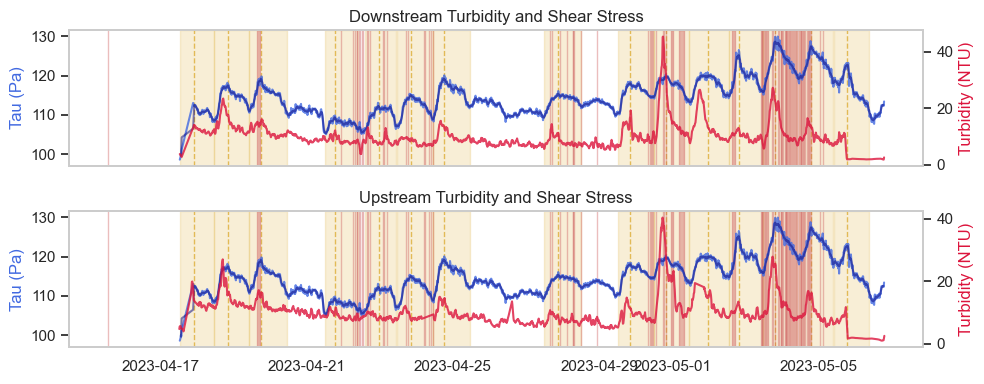

In [47]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")

colors = ['royalblue', 'crimson']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']

event_color = 'goldenrod'
transport_color = 'indianred'

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau, color=colors[0], alpha=0.8, label="Shear Stress")
    ax_tau.plot(tau_smooth.index, tau_smooth, color="navy", alpha=0.5, label="Smoothed Tau")
    ax_tau.set_ylabel("Tau (Pa)", color=colors[0])
    ax_tau.grid(False)

    ax_turb.plot(sonde.index, sonde["Turbidity FNU"], color=colors[1], alpha=0.8, label="Turbidity")
    ax_turb.set_ylabel("Turbidity (NTU)", color=colors[1])
    ax_turb.grid(False)

    # event windows
    for j, row in events.iterrows():
        ax_tau.axvspan(
            row['start'],
            row['end'],
            color=event_color,
            alpha=event_alpha,
            zorder=0,
            label='Event window' if j == 0 else None
        )
        ax_tau.axvline(
            row['peak_time'],
            color=event_color,
            linestyle='--',
            linewidth=1,
            alpha=0.7,
            zorder=1,
            label='Event peak' if j == 0 else None
        )

    # tauc exceedance windows
    for j, row in tauc_exceedance_events.iterrows():
        ax_tau.axvspan(
            row["start"], row["end"],
            color=transport_color,
            alpha=0.4,
            zorder=1,
            label="τc exceedance" if j == 0 else None
        )

    ax_tau.set_title(titles[i])
plt.tight_layout()
plt.show()

In [48]:
event_tauc_summary.to_csv('spring_event_tauc_summary.csv', index=False)